Loading dataset...
Dataset "AB_NYC_2019.csv" loaded!


C:\Users\HP OMEN\AppData\Local\Temp\ipykernel_7040\101831744.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='neighbourhood_group', data=df_clean, palette='Set2')


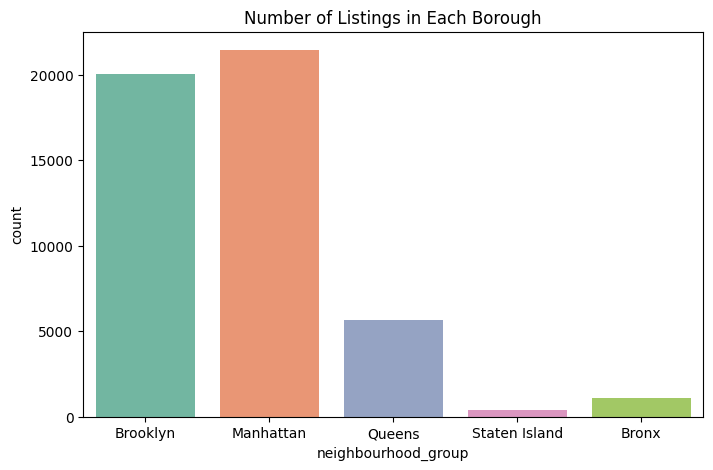

C:\Users\HP OMEN\AppData\Local\Temp\ipykernel_7040\101831744.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='room_type', y='price', data=df_clean, ci=None, palette='Pastel1')
C:\Users\HP OMEN\AppData\Local\Temp\ipykernel_7040\101831744.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='room_type', y='price', data=df_clean, ci=None, palette='Pastel1')


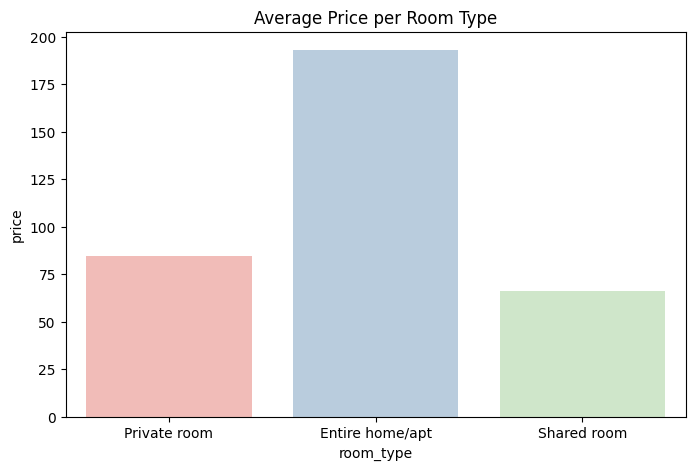

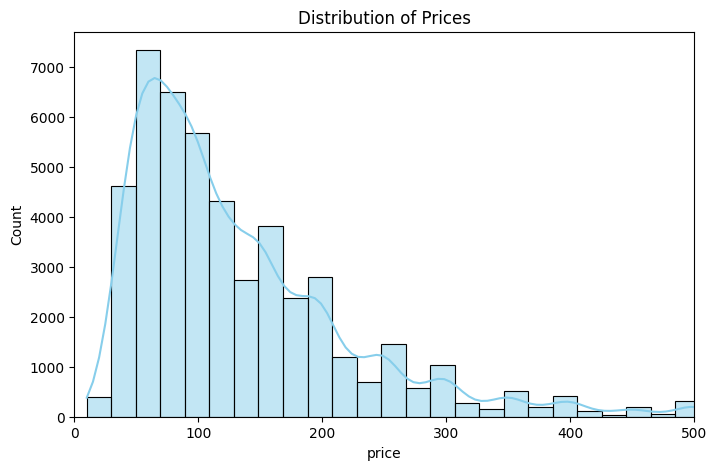

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Data Cleaning Function ---
def clean_airbnb_data(file_path):
    print("Loading dataset...")
    df = pd.read_csv(file_path)
    print(f'Dataset "{file_path}" loaded!')

    # Filling missing review values
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

    # Dropping columns not needed for basic visualization
    df.drop(['last_review', 'host_name', 'name'], axis=1, inplace=True, errors='ignore')

    # Filtering for a "normal" price range to make charts readable
    df = df[(df['price'] > 0) & (df['price'] < 1000)]

    return df

# --- Step 2: Execution & Simple Visualizations ---
df_clean = clean_airbnb_data('AB_NYC_2019.csv')

# Visualization 1: Count of listings per Borough (Simple Bar Chart)
plt.figure(figsize=(8, 5))
sns.countplot(x='neighbourhood_group', data=df_clean, palette='Set2')
plt.title('Number of Listings in Each Borough')
plt.show()

# Visualization 2: Average Price by Room Type (Simple Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(x='room_type', y='price', data=df_clean, ci=None, palette='Pastel1')
plt.title('Average Price per Room Type')
plt.show()

# Visualization 3: Price Distribution (Simple Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], bins=50, color='skyblue', kde=True)
plt.title('Distribution of Prices')
plt.xlim(0, 500) # Zooming in on the most common price points
plt.show()

Loading dataset 'titanic.csv'...
Data cleaned! Generating visualizations...


C:\Users\HP OMEN\AppData\Local\Temp\ipykernel_7040\4088980690.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='magma', ci=None)
C:\Users\HP OMEN\AppData\Local\Temp\ipykernel_7040\4088980690.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='magma', ci=None)


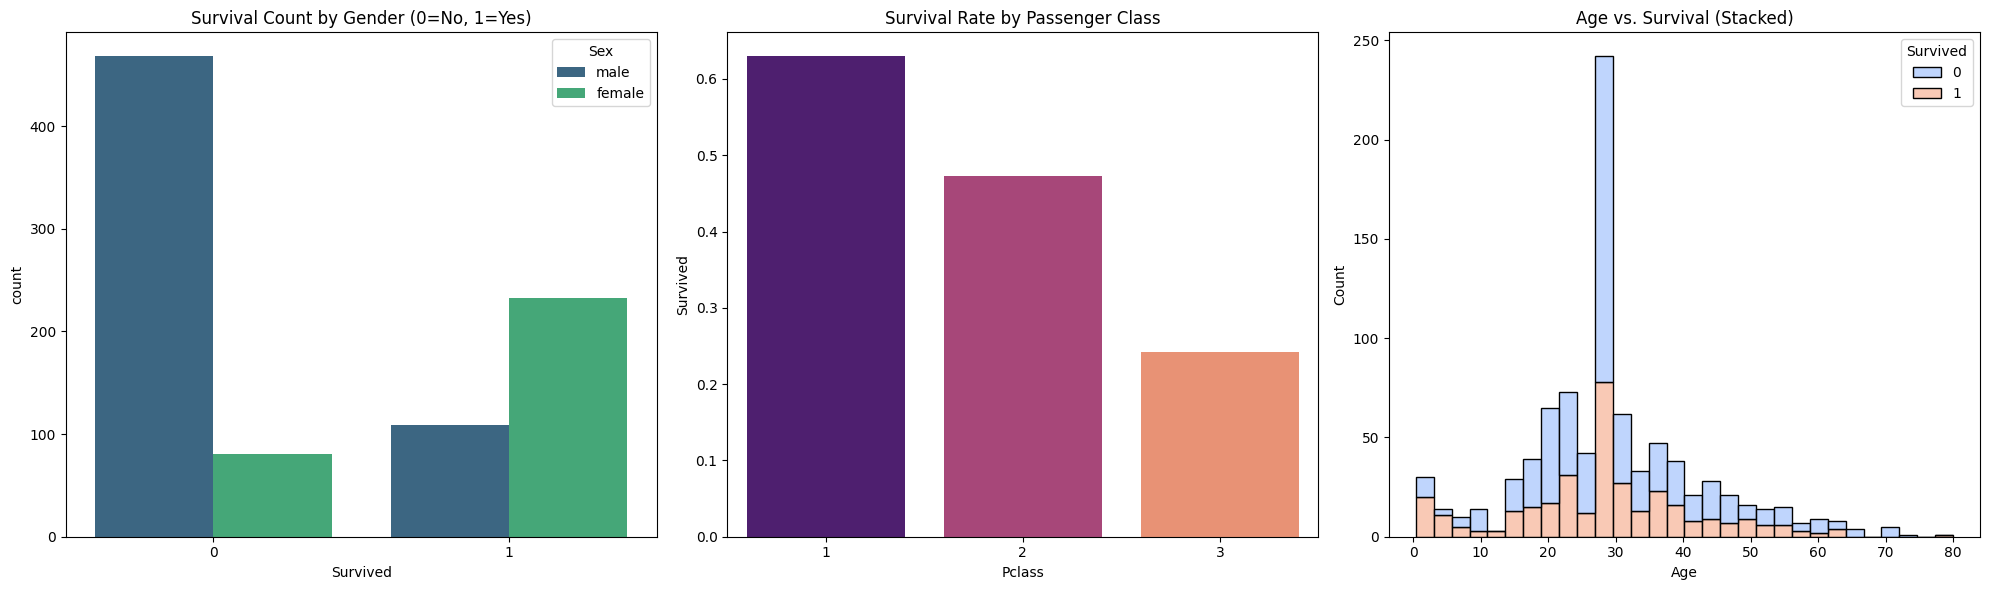

In [7]:


def clean_and_visualize_titanic(file_path):
    print(f"Loading dataset '{file_path}'...")
    df = pd.read_csv(file_path)
    
    # --- 1. Data Cleaning ---
    # Fill missing Age with the median (to handle outliers better)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # Fill missing Embarked with the mode (most common port)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # Drop Cabin (77% nulls) and non-numeric identity columns
    df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True, errors='ignore')
    
    print("Data cleaned! Generating visualizations...")
    
    # --- 2. Visualization Setup ---
    plt.figure(figsize=(20, 6))
    
    # Visual 1: Survival by Gender (Count Plot)
    plt.subplot(1, 3, 1)
    sns.countplot(x='Survived', hue='Sex', data=df, palette='viridis')
    plt.title('Survival Count by Gender (0=No, 1=Yes)')
    
    # Visual 2: Survival Rate by Passenger Class (Bar Plot)
    plt.subplot(1, 3, 2)
    sns.barplot(x='Pclass', y='Survived', data=df, palette='magma', ci=None)
    plt.title('Survival Rate by Passenger Class')
    
    # Visual 3: Age Distribution of Survival (Histogram)
    plt.subplot(1, 3, 3)
    sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette='coolwarm')
    plt.title('Age vs. Survival (Stacked)')
    
    plt.tight_layout()
    plt.show()
    return df

# Run the single-cell pipeline
df_titanic_clean = clean_and_visualize_titanic('titanic.csv')